# London Bicycles Analysis Starter

This notebook connects to BigQuery, loads the analytics marts, and creates starter charts for the final report and executive presentation.

## Setup

Before running this notebook, confirm that dbt has created the analytics tables in `vocal-gist-496900-j8.london_bicycles_analytics`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
from google.cloud import bigquery

PROJECT_ID = "vocal-gist-496900-j8"
DATASET = "london_bicycles_analytics"

client = bigquery.Client(project=PROJECT_ID)
if sns:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use("ggplot")

E0000 00:00:1780200947.373034   17356 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780200947.373355   17356 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780200947.373362   17356 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780200947.373364   17356 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780200947.373366   17356 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


In [2]:
def read_query(sql):
    query_job = client.query(sql)
    result = query_job.result()
    rows = [dict(row.items()) for row in result]
    return pd.DataFrame(rows)


## KPI Summary

These headline metrics summarize the analysis-ready dbt marts.


In [3]:
daily = read_query(f"""
select *
from `{PROJECT_ID}.{DATASET}.mart_daily_demand`
order by trip_date
""")

station_activity = read_query(f"""
select *
from `{PROJECT_ID}.{DATASET}.mart_station_activity`
""")

kpis = pd.DataFrame({
    "metric": [
        "Total trips in mart_daily_demand",
        "First trip date",
        "Last trip date",
        "Average daily trips",
        "Highest daily trips",
        "Stations with activity",
    ],
    "value": [
        f"{daily['trip_count'].sum():,.0f}",
        daily['trip_date'].min(),
        daily['trip_date'].max(),
        f"{daily['trip_count'].mean():,.0f}",
        f"{daily['trip_count'].max():,.0f}",
        f"{station_activity['station_id'].nunique():,.0f}",
    ]
})

kpis


,metric,value
0,Total trips in mart_daily_demand,"83,375,574"
1,First trip date,2015-01-04
2,Last trip date,2023-01-15
3,Average daily trips,"28,592"
4,Highest daily trips,"72,295"
5,Stations with activity,"1,629"


## Daily Demand

This chart shows how demand changes over time. Use it to identify seasonality, shocks, and long-term usage patterns.


In [4]:
daily.head()


,trip_date,trip_count,active_bike_count,avg_duration_minutes,median_duration_minutes
0,2015-01-04,9200,4154,24.446847826,13
1,2015-01-05,20305,6887,18.503422802,12
2,2015-01-06,20552,6771,15.582376411,11
3,2015-01-07,22255,6988,20.861469333,12
4,2015-01-08,15539,5498,15.319325568,11


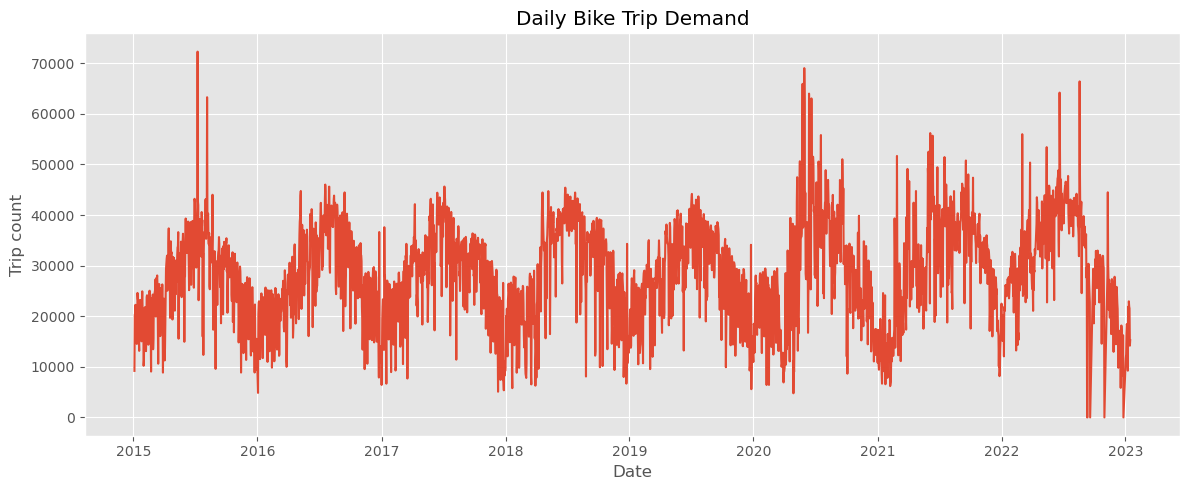

In [5]:
plt.figure(figsize=(12, 5))
if sns:
    sns.lineplot(data=daily, x="trip_date", y="trip_count")
else:
    plt.plot(daily["trip_date"], daily["trip_count"])
plt.title("Daily Bike Trip Demand")
plt.xlabel("Date")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()


In [6]:
top_days = daily.sort_values("trip_count", ascending=False).head(10)
top_days[["trip_date", "trip_count", "avg_duration_minutes", "median_duration_minutes"]]


,trip_date,trip_count,avg_duration_minutes,median_duration_minutes
186,2015-07-09,72295,43.609502732,22
1973,2020-05-30,69032,49.949718971,25
2784,2022-08-19,66409,27.141667545,19
1968,2020-05-25,65924,50.491414356,25
2725,2022-06-21,64194,24.895753497,19
1987,2020-06-13,63994,43.588758321,24
214,2015-08-06,63281,34.417534489,20
1994,2020-06-20,63048,38.794172694,22
1974,2020-05-31,62001,47.918920663,25
1988,2020-06-14,56622,42.425753241,23


## Monthly Demand

Monthly aggregation makes the long-term pattern easier to read than daily values.


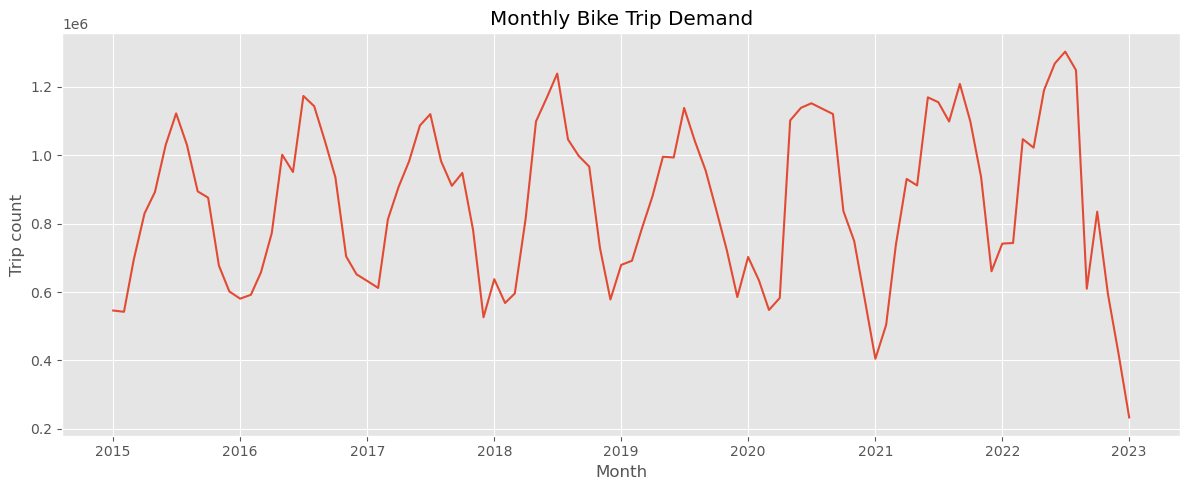

,trip_month,trip_count,avg_duration_minutes
90,2022-07-01,1303376,21.719143
89,2022-06-01,1268701,22.103569
91,2022-08-01,1249038,21.675539
42,2018-07-01,1239205,22.7214
80,2021-09-01,1208914,20.108508
88,2022-05-01,1190590,20.425308
18,2016-07-01,1173700,24.169882
77,2021-06-01,1169603,21.723098
41,2018-06-01,1168667,21.861729
78,2021-07-01,1155434,22.051558


In [7]:
monthly = daily.copy()
monthly["trip_month"] = pd.to_datetime(monthly["trip_date"]).dt.to_period("M").dt.to_timestamp()
monthly = monthly.groupby("trip_month", as_index=False).agg(
    trip_count=("trip_count", "sum"),
    avg_duration_minutes=("avg_duration_minutes", "mean")
)

plt.figure(figsize=(12, 5))
if sns:
    sns.lineplot(data=monthly, x="trip_month", y="trip_count")
else:
    plt.plot(monthly["trip_month"], monthly["trip_count"])
plt.title("Monthly Bike Trip Demand")
plt.xlabel("Month")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()

monthly.sort_values("trip_count", ascending=False).head(10)


## Hourly Demand

This view helps determine whether usage is commute-heavy, leisure-heavy, or evenly distributed.


In [8]:
hourly = read_query(f"""
select *
from `{PROJECT_ID}.{DATASET}.mart_hourly_demand`
order by trip_start_hour
""")

hourly


,trip_start_hour,trip_count,avg_duration_minutes
0,0,865889,28.529844299
1,1,568514,33.430294944
2,2,366828,35.246824352
3,3,252252,36.435953663
4,4,206163,31.40636325
5,5,339731,21.434087754
6,6,1428153,15.482369419
7,7,4103742,15.366094555
8,8,7564750,15.831628327
9,9,4666047,17.411231641


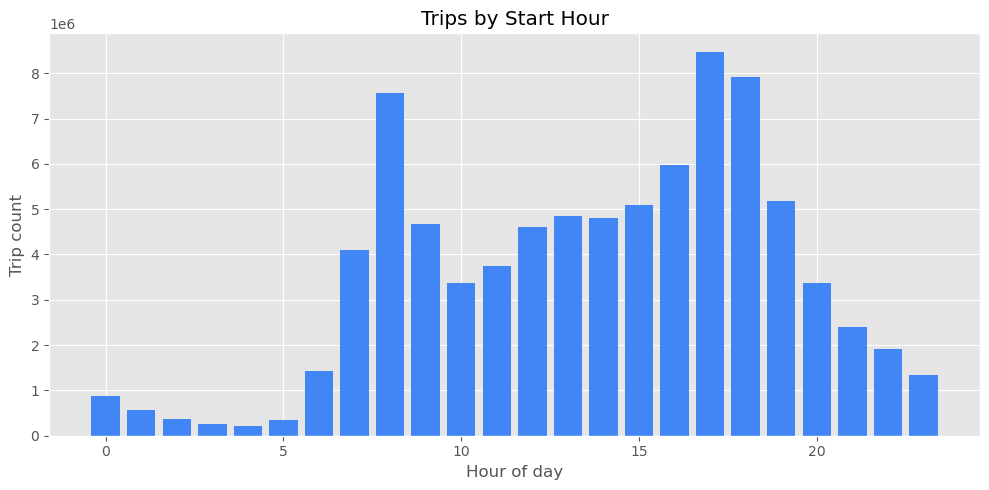

,trip_start_hour,trip_count,avg_duration_minutes
17,17,8458650,20.790878836
18,18,7919387,20.645180732
8,8,7564750,15.831628327
16,16,5977853,23.981424315
19,19,5170904,20.909950578


In [9]:
plt.figure(figsize=(10, 5))
if sns:
    sns.barplot(data=hourly, x="trip_start_hour", y="trip_count", color="#4285F4")
else:
    plt.bar(hourly["trip_start_hour"], hourly["trip_count"], color="#4285F4")
plt.title("Trips by Start Hour")
plt.xlabel("Hour of day")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()

hourly.sort_values("trip_count", ascending=False).head(5)


## Weekday and Weekend Demand

This table and chart compare demand across the week and separate weekday from weekend behavior.


In [10]:
weekday = read_query(f"""
select *
from `{PROJECT_ID}.{DATASET}.mart_weekday_demand`
order by day_of_week_number
""")

weekday


,day_of_week_number,day_of_week_name,is_weekend,trip_count,avg_duration_minutes
0,1,Sunday,True,10327236,28.610884682
1,2,Monday,False,11703934,19.824214372
2,3,Tuesday,False,12609391,18.253032822
3,4,Wednesday,False,12588042,19.45807094
4,5,Thursday,False,12671195,19.647612992
5,6,Friday,False,12193867,20.792148569
6,7,Saturday,True,11281909,27.773935473


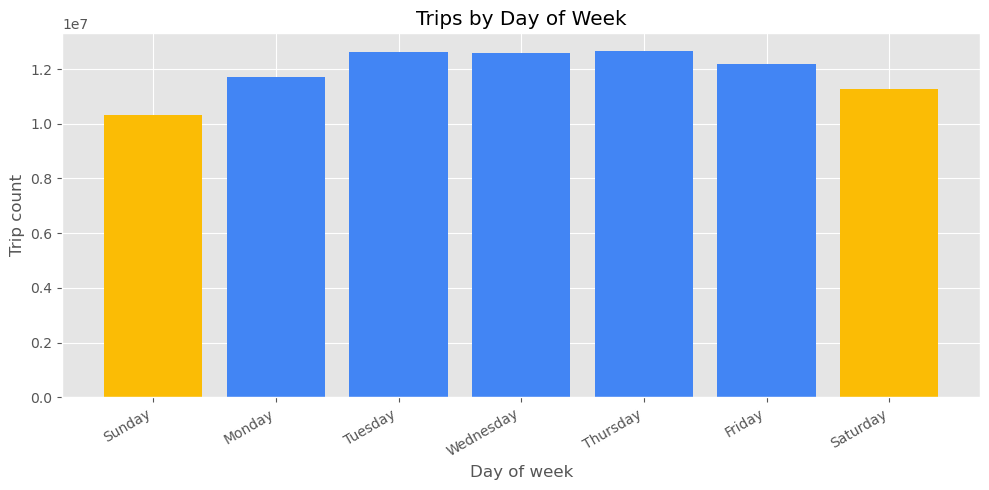

,is_weekend,trip_count,avg_duration_minutes
0,False,61766429,19.595016
1,True,21609145,28.19241


In [11]:
plt.figure(figsize=(10, 5))
if sns:
    sns.barplot(data=weekday, x="day_of_week_name", y="trip_count", hue="is_weekend")
else:
    colors = ["#FBBC05" if x else "#4285F4" for x in weekday["is_weekend"]]
    plt.bar(weekday["day_of_week_name"], weekday["trip_count"], color=colors)
plt.title("Trips by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Trip count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

weekday_summary = weekday.groupby("is_weekend", as_index=False).agg(
    trip_count=("trip_count", "sum"),
    avg_duration_minutes=("avg_duration_minutes", "mean")
)
weekday_summary


## Station Activity

This identifies the busiest stations by combined arrivals and departures.


In [12]:
top_stations = station_activity.copy()
top_stations["station_name"] = top_stations["station_name"].fillna("Unknown station")
top_stations = top_stations.sort_values("total_activity_count", ascending=False).head(20)
top_stations[["station_id", "station_name", "departure_count", "arrival_count", "total_activity_count", "net_departure_count"]]


,station_id,station_name,departure_count,arrival_count,total_activity_count,net_departure_count
470,191,"Hyde Park Corner, Hyde Park",658129,655670,1313799,2459
684,14,"Argyle Street, Kings Cross",579703,571662,1151365,8041
769,154,"Waterloo Station 3, Waterloo",512990,492656,1005646,20334
197,303,"Albert Gate, Hyde Park",451863,454096,905959,-2233
699,307,"Black Lion Gate, Kensington Gardens",451696,442809,894505,8887
0,194,"Hop Exchange, The Borough",374920,502401,877321,-127481
761,374,"Waterloo Station 1, Waterloo",407848,390908,798756,16940
652,213,"Wellington Arch, Hyde Park",386105,379828,765933,6277
27,217,"Wormwood Street, Liverpool Street",342606,359152,701758,-16546
582,248,"Triangle Car Park, Hyde Park",348269,343630,691899,4639


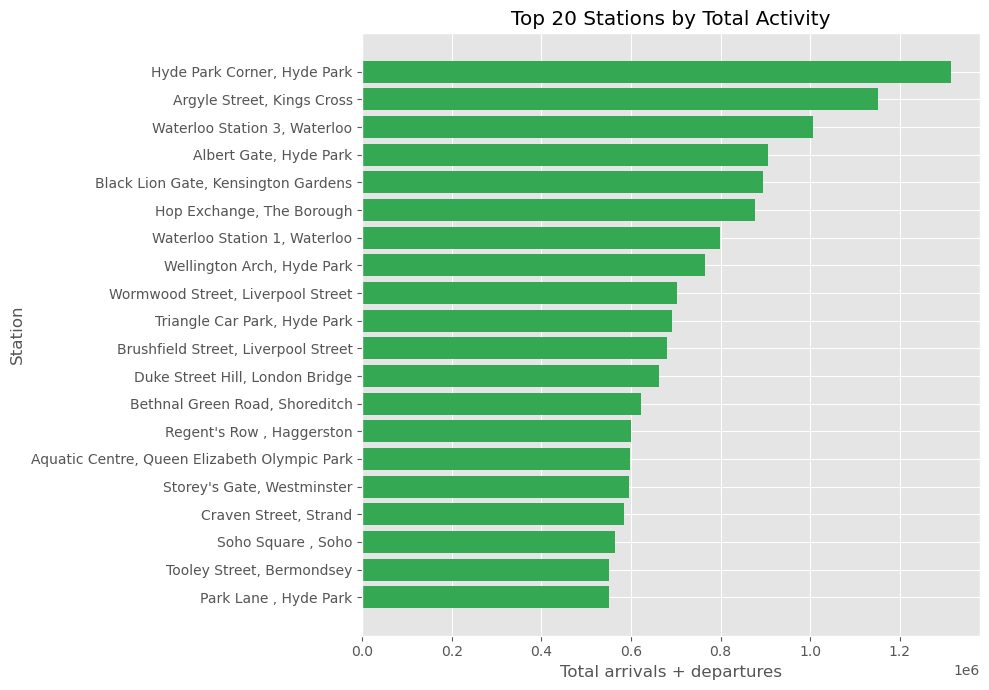

In [13]:
plt.figure(figsize=(10, 7))
plot_data = top_stations.sort_values("total_activity_count", ascending=True)
if sns:
    sns.barplot(data=plot_data, y="station_name", x="total_activity_count", color="#34A853")
else:
    plt.barh(plot_data["station_name"], plot_data["total_activity_count"], color="#34A853")
plt.title("Top 20 Stations by Total Activity")
plt.xlabel("Total arrivals + departures")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


## Station Imbalance

Positive net departures mean more trips start than end at the station. Negative net departures mean more trips end than start there. These are useful for bike rebalancing recommendations.


In [14]:
imbalance = station_activity.copy()
imbalance["station_name"] = imbalance["station_name"].fillna("Unknown station")
imbalance["absolute_imbalance"] = imbalance["net_departure_count"].abs()
imbalance = imbalance[imbalance["total_activity_count"] > 0]

highest_departure_pressure = imbalance.sort_values("net_departure_count", ascending=False).head(10)
highest_arrival_pressure = imbalance.sort_values("net_departure_count", ascending=True).head(10)

highest_departure_pressure[["station_id", "station_name", "departure_count", "arrival_count", "net_departure_count"]]


,station_id,station_name,departure_count,arrival_count,net_departure_count
784,361,"Waterloo Station 2, Waterloo",243259,175395,67864
783,574,"Eagle Wharf Road, Hoxton",215140,173774,41366
782,93,"Cloudesley Road, Angel",90573,56171,34402
781,222,"Knightsbridge, Hyde Park",110194,81400,28794
780,45,"Boston Place, Marylebone",152690,125270,27420
779,524,"Lancaster Gate , Bayswater",127663,100933,26730
778,189,"Claremont Square, Angel",69963,44864,25099
777,326,"Graham Street, Angel",155660,131612,24048
776,42,"Wenlock Road , Hoxton",123430,100118,23312
775,225,"Notting Hill Gate Station, Notting Hill",190611,168130,22481


In [15]:
highest_arrival_pressure[["station_id", "station_name", "departure_count", "arrival_count", "net_departure_count"]]


,station_id,station_name,departure_count,arrival_count,net_departure_count
0,194,"Hop Exchange, The Borough",374920,502401,-127481
1,66,"Holborn Circus, Holborn",219536,298444,-78908
2,228,"St. James's Square, St. James's",213229,281310,-68081
3,251,"Brushfield Street, Liverpool Street",314535,366726,-52191
4,64,"William IV Street, Strand",204712,249766,-45054
5,71,"Newgate Street , St. Paul's",228433,270861,-42428
6,109,"Soho Square , Soho",260994,302789,-41795
7,579,"Queen Street 2, Bank",194365,235343,-40978
8,112,"Stonecutter Street, Holborn",81740,112157,-30417
785,335,Unknown station,145263,173788,-28525


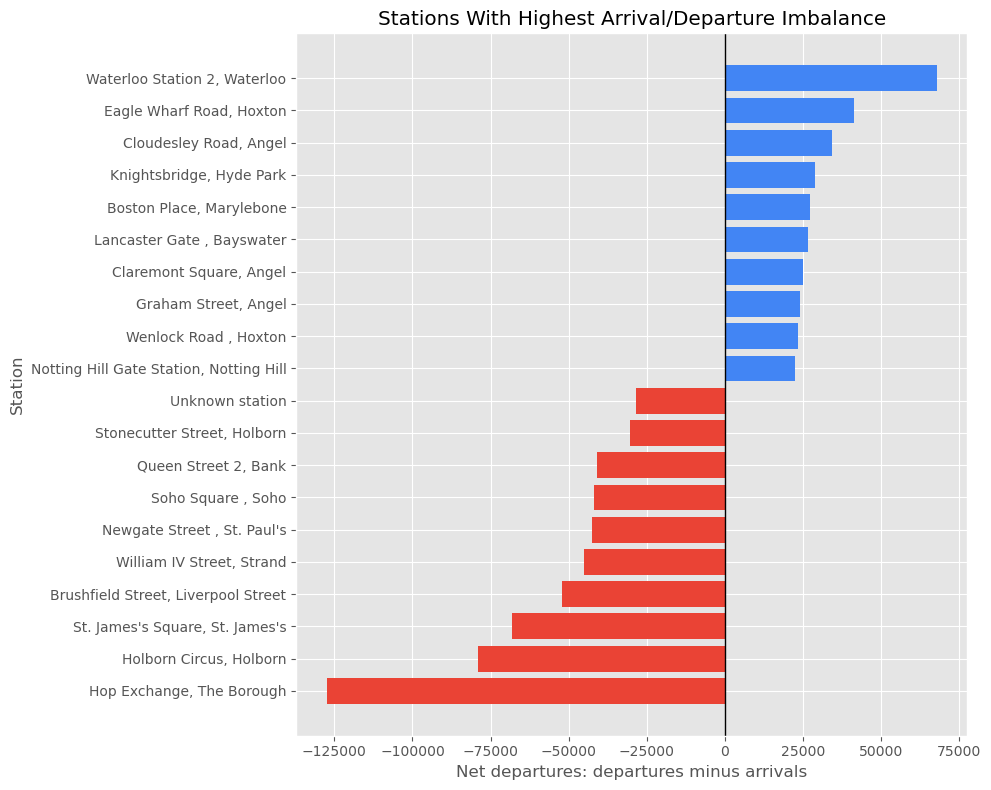

In [16]:
imbalance_plot = pd.concat([
    highest_departure_pressure.assign(imbalance_type="More departures"),
    highest_arrival_pressure.assign(imbalance_type="More arrivals")
])
imbalance_plot = imbalance_plot.sort_values("net_departure_count")

plt.figure(figsize=(10, 8))
colors = ["#EA4335" if x < 0 else "#4285F4" for x in imbalance_plot["net_departure_count"]]
plt.barh(imbalance_plot["station_name"], imbalance_plot["net_departure_count"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Stations With Highest Arrival/Departure Imbalance")
plt.xlabel("Net departures: departures minus arrivals")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


## Analysis Findings Draft

Run the cells above, then use the output below as the starting point for the report and slides.


In [17]:
peak_hour = hourly.sort_values("trip_count", ascending=False).iloc[0]
peak_day = weekday.sort_values("trip_count", ascending=False).iloc[0]
busiest_station = top_stations.sort_values("total_activity_count", ascending=False).iloc[0]
departure_hotspot = highest_departure_pressure.iloc[0]
arrival_hotspot = highest_arrival_pressure.iloc[0]

findings = [
    f"Peak hour: {int(peak_hour['trip_start_hour'])}:00 with {peak_hour['trip_count']:,.0f} trips.",
    f"Busiest day of week: {peak_day['day_of_week_name']} with {peak_day['trip_count']:,.0f} trips.",
    f"Busiest station: {busiest_station['station_name']} with {busiest_station['total_activity_count']:,.0f} total arrivals and departures.",
    f"Highest departure pressure: {departure_hotspot['station_name']} with net departures of {departure_hotspot['net_departure_count']:,.0f}.",
    f"Highest arrival pressure: {arrival_hotspot['station_name']} with net departures of {arrival_hotspot['net_departure_count']:,.0f}.",
]

for finding in findings:
    print("- " + finding)


- Peak hour: 17:00 with 8,458,650 trips.
- Busiest day of week: Thursday with 12,671,195 trips.
- Busiest station: Hyde Park Corner, Hyde Park with 1,313,799 total arrivals and departures.
- Highest departure pressure: Waterloo Station 2, Waterloo with net departures of 67,864.
- Highest arrival pressure: Hop Exchange, The Borough with net departures of -127,481.


## Recommendations Draft

- Prioritize bike rebalancing around stations with high positive net departures.
- Monitor stations with high negative net departures for dock availability pressure.
- Staff or operationally monitor the highest-demand hours.
- Use weekday/weekend patterns to tune service levels.
- Exclude invalid or missing durations from duration-based KPIs.
- Note that some historical station IDs do not match the current station reference table.
